# Task 1: Problem Identification

The given dataset represents an **Image Classification** problem in Computer Vision.

The dataset contains four image categories:
- Dent
- Scratch
- Stain
- Normal

Each image belongs to one specific class based on the type of surface condition shown in the image. The objective of the model is to correctly classify an input image into its respective category.

This problem is suitable for image classification because the task involves assigning a single label to an entire image rather than detecting object locations or segmenting different regions of the image. The CNN model learns visual patterns such as dents, scratches, stains, and normal surfaces from the training data and predicts the correct class for unseen images.

Therefore, Image Classification is the most appropriate computer vision problem type for this dataset.

# Task 2: Dataset Exploration

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt

In [1]:
!unzip images.zipA

Archive:  images.zip.zip
replace images/scratch/scratch_037.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: images/scratch/scratch_037.png  
  inflating: images/scratch/scratch_109.png  
  inflating: images/scratch/scratch_069.png  
  inflating: images/scratch/scratch_017.png  
  inflating: images/scratch/scratch_098.png  
  inflating: images/scratch/scratch_032.png  
  inflating: images/scratch/scratch_012.png  
  inflating: images/scratch/scratch_004.png  
  inflating: images/scratch/scratch_002.png  
  inflating: images/scratch/scratch_001.png  
  inflating: images/scratch/scratch_009.png  
  inflating: images/scratch/scratch_083.png  
  inflating: images/scratch/scratch_086.png  
  inflating: images/scratch/scratch_008.png  
  inflating: images/scratch/scratch_108.png  
  inflating: images/scratch/scratch_049.png  
  inflating: images/scratch/scratch_027.png  
  inflating: images/scratch/scratch_038.png  
  inflating: images/.DS_Store        
  inflating: images/scratch/s

## Load Dataset
Loading dataset folders, class names and number of classes

In [4]:
dataset_path = "/content/images"

classes = os.listdir(dataset_path)

classes.remove(".DS_Store")

print("Classes in Dataset:")
print(classes)

print("\nNumber of Classes:", len(classes))

Classes in Dataset:
['stain', 'normal', 'scratch', 'dent']

Number of Classes: 4


## Number of Images Per Class
Counting images present in each category.

In [5]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = os.listdir(class_path)

    class_counts[cls] = len(images)

    print(f"{cls}: {len(images)} images")


stain: 120 images
normal: 120 images
scratch: 120 images
dent: 120 images


## Sample Images from Each Class
Displaying sample images from all categories.

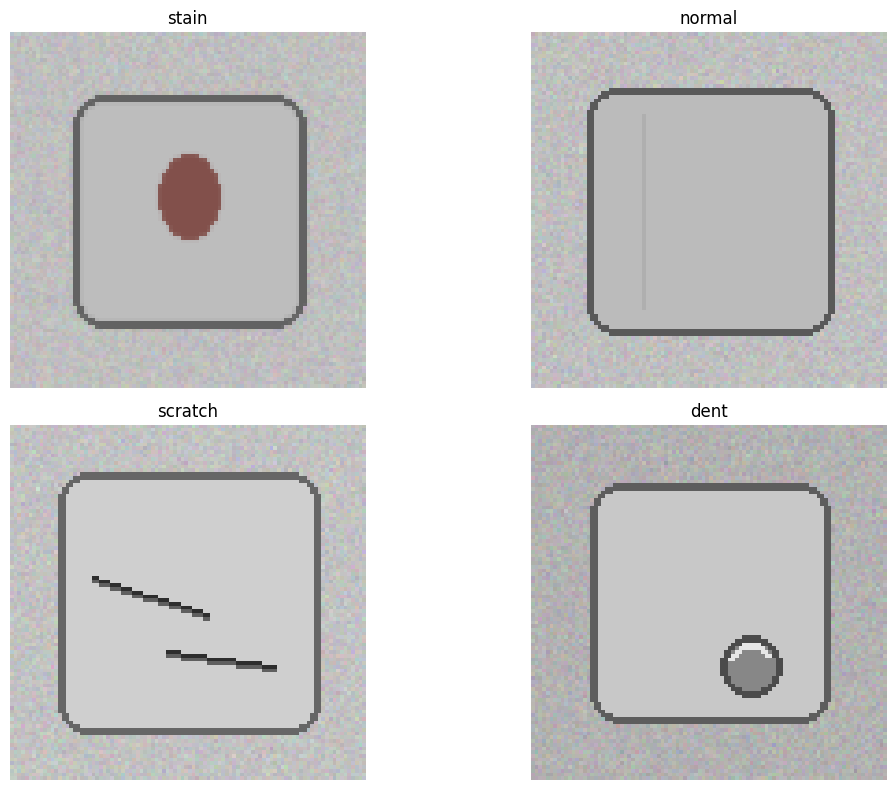

In [6]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

## Image Dimensions
Checking image sizes in the dataset.

In [7]:
for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    print(f"{cls}: {img.size}")


stain: (96, 96)
normal: (96, 96)
scratch: (96, 96)
dent: (96, 96)


## Dataset Imbalance Analysis
Analyzing whether the dataset is balanced across all classes.


In [9]:

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

stain: 120 images
normal: 120 images
scratch: 120 images
dent: 120 images


The dataset contains four classes:
- dent
- scratch
- normal
- stain

Each class contains 120 images.

This shows that the dataset is perfectly balanced because all classes have an equal number of images. A balanced dataset helps the CNN model learn all categories fairly and reduces bias toward any single class.

## Conclusion

The dataset exploration process helped in understanding the structure and distribution of the image dataset. The dataset contains four balanced classes representing different surface conditions: dent, scratch, stain, and normal.

Sample images and image dimensions were analyzed successfully. Since the dataset is balanced, it is suitable for training a CNN model without major class imbalance issues.

This dataset is appropriate for an image classification problem where the model predicts the correct category based on the input image.

# Task 3: Image Preprocessing

## Import Required Libraries

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Define Image Parameters
Setting image size and batch size for training the CNN model.

In [11]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

## Image Augmentation and Normalization
Applying preprocessing techniques such as:
- Rescaling pixel values
- Rotation
- Zoom
- Horizontal flipping

In [13]:
train_datagen = ImageDataGenerator(
rescale=1./255,
validation_split=0.2,
rotation_range=20,
zoom_range=0.2,
horizontal_flip=True
)


## Load Training Dataset
Loading training images from the dataset directory.


In [14]:
train_data = train_datagen.flow_from_directory(
"/content/images",
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='training'
)

Found 384 images belonging to 4 classes.


## Load Validation Dataset
Loading validation images for model evaluation.

In [15]:
validation_data = train_datagen.flow_from_directory(
"/content/images",
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='validation'
)

Found 96 images belonging to 4 classes.


## Class Labels
Displaying class labels generated during preprocessing.

In [16]:
print("Class Labels:")
print(train_data.class_indices)

Class Labels:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


## Verify Image Shape
Checking image dimensions after preprocessing.

In [17]:
images, labels = next(train_data)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32, 4)



## Conclusion

The image dataset was successfully preprocessed for CNN model training.

The preprocessing steps included:
- Resizing all images to a fixed size of 128 × 128 pixels
- Normalizing pixel values using rescaling
- Applying image augmentation techniques such as rotation, zoom, and horizontal flipping
- Splitting the dataset into training and validation sets

The training dataset contains 384 images, while the validation dataset contains 96 images across 4 classes:
- dent
- normal
- scratch
- stain

The generated batch shape of images is (32, 128, 128, 3), which confirms that the images are correctly formatted for CNN input.
The label batch shape is (32, 4), indicating proper categorical encoding for the four classes.

Overall, the dataset is now fully prepared for CNN model creation and training.

#Task 4: CNN Model Creation

## Import Libraries
Importing TensorFlow and Keras libraries for CNN model creation.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## Build CNN Architecture

Creating the CNN model with convolution, pooling, flatten, dense, and output layers.

In [19]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile CNN Model

Compiling the CNN model using Adam optimizer and categorical crossentropy loss.


In [23]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)


## CNN Model Summary

Displaying the architecture and parameters of the CNN model.



In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Conclusion

A Convolutional Neural Network (CNN) model was successfully created using TensorFlow/Keras for image classification.

The model architecture includes:
- Convolution layers for extracting image features
- ReLU activation functions for non-linearity
- MaxPooling layers for dimensionality reduction
- Flatten layer for converting feature maps into vectors
- Dense layer for learning complex patterns
- Dropout layer to reduce overfitting
- Softmax output layer for multi-class classification

The model was compiled successfully using the Adam optimizer and categorical crossentropy loss function.

The CNN model summary shows that the network contains trainable parameters and is capable of learning patterns from the four image classes:
- dent
- scratch
- normal
- stain

This CNN architecture is suitable for image classification tasks and is ready for model training and evaluation.

#Task 5: Model Training and Evaluation

## Train CNN Model

Training the CNN model using the training dataset and validating using validation dataset.

In [24]:
history = model.fit(
train_data,
validation_data=validation_data,
epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 852ms/step - accuracy: 0.2057 - loss: 1.4418 - val_accuracy: 0.3229 - val_loss: 1.3837
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 832ms/step - accuracy: 0.3229 - loss: 1.3734 - val_accuracy: 0.2604 - val_loss: 1.3557
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 712ms/step - accuracy: 0.3984 - loss: 1.2705 - val_accuracy: 0.5312 - val_loss: 1.1176
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 750ms/step - accuracy: 0.5417 - loss: 1.0621 - val_accuracy: 0.7083 - val_loss: 0.9257
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 755ms/step - accuracy: 0.6719 - loss: 0.8159 - val_accuracy: 0.7083 - val_loss: 0.7482
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 784ms/step - accuracy: 0.7266 - loss: 0.7033 - val_accuracy: 0.8229 - val_loss: 0.5252
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 677ms/step - accuracy: 0.7682 - loss: 0.5520 - val_accuracy: 0.8958 - val_loss: 0.4124
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 746ms/step - accuracy: 0.8125 - loss: 0.4938 - val_accuracy: 

## Training and Validation Accuracy

Visualizing training and validation accuracy of the CNN model.

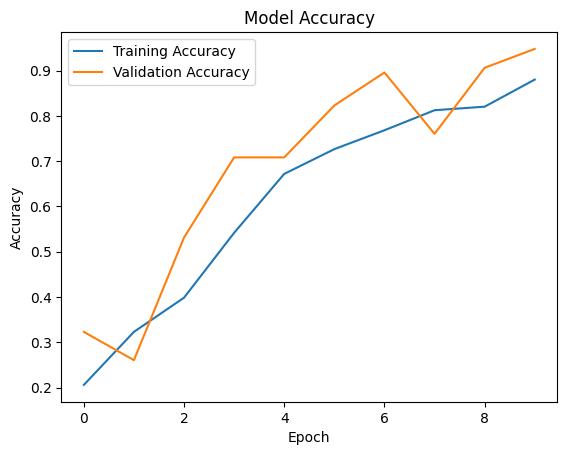

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

## Training and Validation Loss

Visualizing training and validation loss of the CNN model.

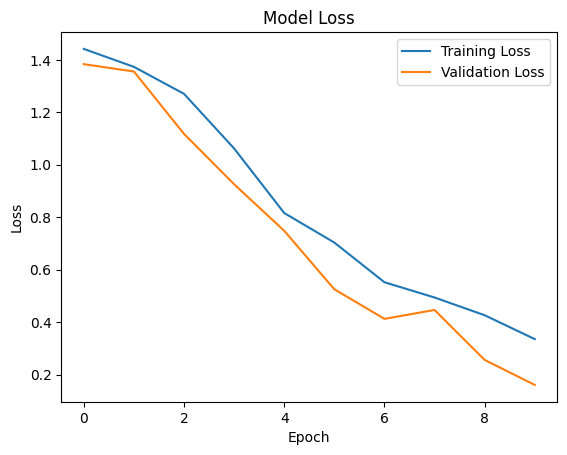

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()


## Model Evaluation

Evaluating the CNN model on validation data.


In [27]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.9375 - loss: 0.1883
Validation Loss: 0.1882651299238205
Validation Accuracy: 0.9375


## Confusion Matrix

Generating confusion matrix to analyze model predictions.


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step


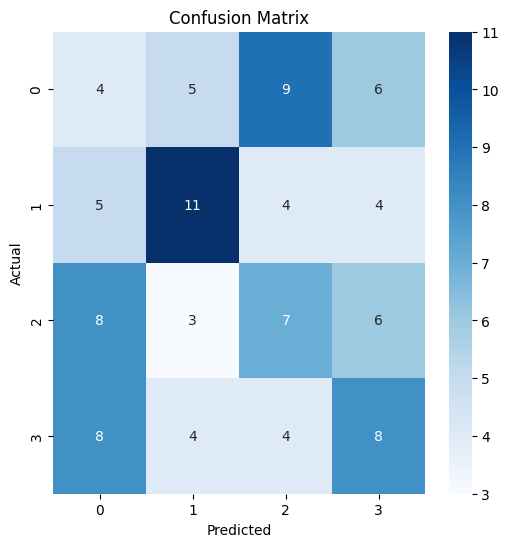

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
predictions = model.predict(validation_data)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


## Sample Predictions

Displaying sample predictions from the validation dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


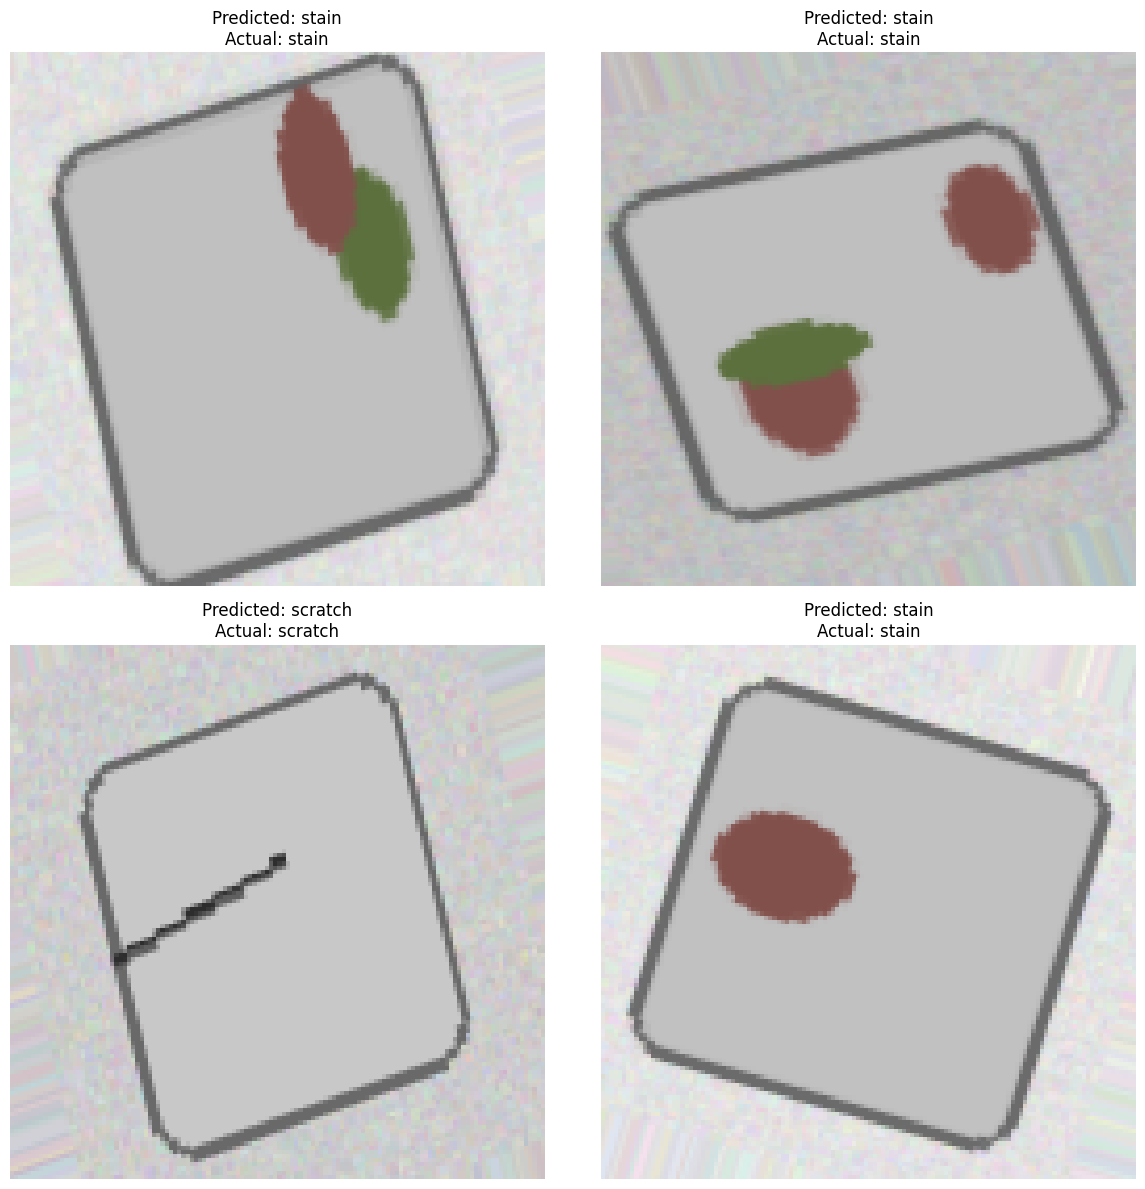

In [29]:
class_names = list(train_data.class_indices.keys())

images, labels = next(validation_data)

predictions = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(4):
    plt.subplot(2,2,i+1)

    plt.imshow(images[i])

    predicted_class = class_names[np.argmax(predictions[i])]

    actual_class = class_names[np.argmax(labels[i])]

    plt.title(f"Predicted: {predicted_class}\nActual: {actual_class}")

    plt.axis('off')

plt.tight_layout()

plt.show()

## Conclusion

The CNN model was successfully trained and evaluated using the image dataset.

The model achieved training and validation accuracy through multiple epochs. Training and validation loss were analyzed using graphs.

A confusion matrix was generated to evaluate prediction performance across all image classes.


# Task 6: CNN Concept Explanation

## 1. What is Convolution?

Convolution is a process where small filters (kernels) move across the image to detect important features such as edges, shapes, textures, and patterns. It helps the CNN understand image details and extract meaningful information from the input image.

---

## 2. Why is Pooling Used?

Pooling is used to reduce the size of feature maps while keeping the important information. It helps in reducing computation, improving efficiency, and preventing overfitting. MaxPooling is commonly used to keep the strongest features from the image.

---

## 3. Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is an activation function that converts negative values into zero and keeps positive values unchanged. It helps the model learn faster, improves performance, and introduces non-linearity so the CNN can learn complex image patterns.

---

## 4. Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

CNNs are better for image data because they automatically detect important visual features like edges, textures, and objects using convolution layers. They also require fewer parameters compared to regular neural networks, making them more efficient and accurate for image classification tasks.

# Task 7: Business Use Case Mapping

## Manufacturing Industry Use Case

This computer vision solution can be used in the manufacturing industry for automatic quality inspection of products.

A CNN model can analyze product images and identify defects such as dents, scratches, stains, or normal surfaces. Instead of manually checking every product, companies can use cameras and AI models to detect damaged items automatically in real time.

This helps in:
- Improving product quality
- Reducing human effort
- Saving inspection time
- Minimizing defective product delivery
- Increasing production efficiency

For example, automobile, electronics, and metal manufacturing companies can use this system to detect surface defects before products are shipped to customers.